In [ ]:
import pandas as pd
import numpy as np


In [ ]:
!ls

fear_greed_index.csv  historical_data.csv  sample_data


In [ ]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

In [ ]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print(sentiment.shape)
print(trades.shape)

print(sentiment.isnull().sum())
print(trades.isnull().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
print(sentiment.shape)
print(trades.shape)

print(sentiment.isnull().sum())
print(trades.isnull().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [ ]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])


In [ ]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [ ]:
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [ ]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [ ]:
print(trades['date'].head())
print(sentiment['date'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [ ]:
print(trades['date'].nunique())
print(sentiment['date'].nunique())

1
2644


In [ ]:
set(trades['date']).intersection(set(sentiment['date']))

set()

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [ ]:
sentiment['date'] = sentiment['date'].dt.normalize()
trades['date'] = trades['Timestamp'].dt.normalize()

In [ ]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left')

In [ ]:
merged['classification'].isnull().sum()

np.int64(211224)

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')


In [ ]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
trades['date'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

In [ ]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [ ]:
merged['classification'].isnull().sum()

np.int64(211224)

In [3]:
trades.columns

NameError: name 'trades' is not defined

In [4]:
import pandas as pd

In [8]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

/tmp/ipykernel_4819/1297548522.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('/content/historical_data.csv')


In [9]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')
trades['date'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['date'] = sentiment['date'].dt.strftime('%Y-%m-%d')

In [12]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

In [13]:
trades['date'] = trades['Timestamp'].dt.normalize()
sentiment['date'] = sentiment['date'].dt.normalize()

In [14]:
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

In [15]:
print("Trades:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades: 1970-01-01 00:00:00 to 1970-01-01 00:00:00
Sentiment: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [16]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

In [17]:
trades['date'] = trades['Timestamp IST'].dt.normalize()

In [18]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['date'] = sentiment['date'].dt.normalize()

In [19]:
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

In [20]:
print("Trades:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades: 2023-01-05 00:00:00 to 2025-12-04 00:00:00
Sentiment: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [21]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [22]:
merged['classification'].isnull().sum()

np.int64(16975)

In [23]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,8.634040
Extreme Greed,452.808634
Fear,231.194976
Greed,99.221918
Neutral,37.430126


In [24]:
merged['win'] = merged['Closed PnL'] > 0
merged.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.457789
Extreme Greed,0.460483
Fear,0.413040
Greed,0.483662
Neutral,0.478885


In [25]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5075.746684
Extreme Greed,5971.483696
Fear,9129.282783
Greed,7382.001922
Neutral,8181.391005


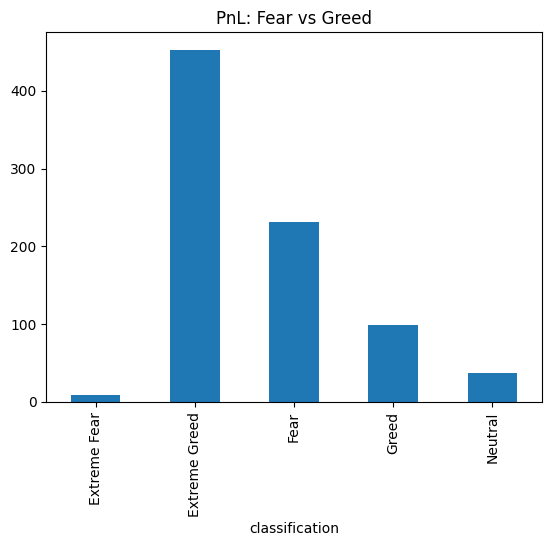

In [26]:
import matplotlib.pyplot as plt

merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Fear vs Greed")
plt.show()

In [27]:
merged.groupby('classification').size()

,0
classification,
Extreme Fear,1149
Extreme Greed,2113
Fear,6411
Greed,6488
Neutral,1184


In [28]:
merged['volume_group'] = merged['Size USD'].apply(
    lambda x: 'High' if x > merged['Size USD'].median() else 'Low'
)

In [29]:
merged.groupby(['classification','volume_group'])['Closed PnL'].mean()

classification  volume_group
Extreme Fear    High             16.902166
                Low               1.504959
Extreme Greed   High            843.995785
                Low              65.673327
Fear            High            439.148925
                Low               9.225426
Greed           High            182.331380
                Low              10.989089
Neutral         High             67.160851
                Low               6.781472
Name: Closed PnL, dtype: float64